# Q-Alchemy feasibility example: H₂ real-time evolution

This notebook demonstrates the hosted `FeasibilityService` with a small but physically meaningful
quantum-chemistry workload.

We use molecular hydrogen, H₂, at an internuclear distance of **0.735 Å** in the **STO-3G**
basis. After parity mapping and the standard two-qubit reduction, the electronic Hamiltonian is

\[
H =
-1.052373245772859\,II
+0.39793742484318045\,IZ
-0.39793742484318045\,ZI
-0.01128010425623538\,ZZ
+0.18093119978423156\,XX.
\]

The coefficients are the same reduced H₂ Hamiltonian used in the Qiskit Nature / Qiskit
Algorithms documentation.

The experiment starts from the H₂ **Hartree–Fock reference wavefunction** and applies one
first-order Trotter step of the molecular Hamiltonian. This is a compact example of
real-time electronic-structure simulation: state preparation is followed by physically
motivated molecular evolution, and the relevant Hamiltonian Pauli terms are measured.

References:

- Qiskit Nature H₂ example:
  https://qiskit-community.github.io/qiskit-nature/getting_started.html
- Qiskit Nature parity-mapper migration guide (reduced H₂ Hamiltonian):
  https://qiskit-community.github.io/qiskit-nature/migration/0.6_c_qubit_converter.html

### What the notebook returns

At the end we display exactly three user-facing results:

1. `report.format_summary()`
2. the server-produced experiment diagram
3. the returned logical quantum circuit (`P + U`)

The notebook uses `QuantumExecutionPolicy.COMPARE` so the configured Aer quantum target is
executed even though this two-qubit problem is classically easy. This makes both feasibility
paths visible in one example.

## Requirements

The hosted call requires a Q-Alchemy API key in either `Q_ALCHEMY_API_KEY` or
`PINEXQ_API_KEY`.

For a source checkout:

```bash
uv sync --locked --extra qiskit --extra examples --extra visualization
```

For an installed SDK:

```bash
pip install "q-alchemy-sdk-py[qiskit,examples,visualization]"
```

No IBM Quantum credentials are required: the quantum target in this notebook is Aer.

In [1]:
from __future__ import annotations

from IPython.display import display

from q_alchemy import (
    Circuit,
    CircuitCompressionConfig,
    EvidenceCollectionConfig,
    FeasibilityPolicy,
    FeasibilityRequest,
    FeasibilityService,
    MeasurementPlan,
    PauliObservable,
    QuantumExecutionPolicy,
    QuantumExperiment,
    SolutionCriteria,
    State,
)

## 1. Molecular data

The reduced H₂ Hamiltonian acts on two qubits. Qiskit Pauli strings are written in
`q₁ q₀` order, so `IZ` acts with \(Z\) on qubit 0 and `ZI` acts with \(Z\) on qubit 1.

The identity term contributes only a global phase to real-time evolution, so we keep it in
the molecular data but omit it from the circuit synthesis.

In [2]:
H2_HAMILTONIAN = {
    "II": -1.052373245772859,
    "IZ": +0.39793742484318045,
    "ZI": -0.39793742484318045,
    "ZZ": -0.01128010425623538,
    "XX": +0.18093119978423156,
}

EVOLUTION_TIME = 0.25  # atomic units
SHOTS = 4096

H2_HAMILTONIAN

{'II': -1.052373245772859,
 'IZ': 0.39793742484318045,
 'ZI': -0.39793742484318045,
 'ZZ': -0.01128010425623538,
 'XX': 0.18093119978423156}

## 2. Build a chemistry-motivated evolution

For a Pauli operator \(P\),

\[
e^{-i\,c\,t\,P}
\]

can be implemented with a Pauli-basis change followed by an `RZ(2 c t)` rotation.

The function below builds a **single first-order Trotter step** for the non-identity part
of the H₂ Hamiltonian. The initial molecular wavefunction is the parity-reduced
Hartree–Fock determinant \(|01\rangle\).

In [3]:
def h2_trotter_qasm(time: float = EVOLUTION_TIME) -> str:
    """Return one first-order Trotter step for the reduced H2 Hamiltonian."""

    def rz_angle(coefficient: float) -> float:
        return 2.0 * coefficient * time

    qasm = [
        "OPENQASM 3.0;",
        'include "stdgates.inc";',
        "qubit[2] q;",
        "",
        "// exp(-i t * c_IZ * IZ): Z on q[0]",
        f"rz({rz_angle(H2_HAMILTONIAN['IZ']):.17g}) q[0];",
        "",
        "// exp(-i t * c_ZI * ZI): Z on q[1]",
        f"rz({rz_angle(H2_HAMILTONIAN['ZI']):.17g}) q[1];",
        "",
        "// exp(-i t * c_ZZ * ZZ)",
        "cx q[0], q[1];",
        f"rz({rz_angle(H2_HAMILTONIAN['ZZ']):.17g}) q[1];",
        "cx q[0], q[1];",
        "",
        "// exp(-i t * c_XX * XX)",
        "h q[0];",
        "h q[1];",
        "cx q[0], q[1];",
        f"rz({rz_angle(H2_HAMILTONIAN['XX']):.17g}) q[1];",
        "cx q[0], q[1];",
        "h q[0];",
        "h q[1];",
    ]
    return "\n".join(qasm)


def build_experiment() -> QuantumExperiment:
    # In the two-qubit parity-reduced representation the H2 Hartree-Fock
    # reference is |01> in Qiskit's |q1 q0> basis ordering.
    hartree_fock = State.dense(
        [0.0, 1.0, 0.0, 0.0],
        metadata={
            "molecule": "H2",
            "bond_length_angstrom": 0.735,
            "basis": "STO-3G",
            "state": "Hartree-Fock reference",
            "mapping": "ParityMapper with two-qubit reduction",
        },
    )

    # These four Pauli terms are the non-trivial components of the molecular
    # electronic Hamiltonian. They are direct diagnostics, not estimator data.
    observables = tuple(
        PauliObservable.pauli(
            f"H2-{pauli}",
            pauli,
            metadata={
                "hamiltonian_coefficient": coefficient,
                "purpose": "electronic-Hamiltonian component",
            },
        )
        for pauli, coefficient in H2_HAMILTONIAN.items()
        if pauli != "II"
    )

    return QuantumExperiment(
        target=hartree_fock,
        evolution=Circuit.qasm3(h2_trotter_qasm()),
        measurement_plan=MeasurementPlan(
            observables=observables,
            observable_plan_metadata={
                "molecule": "H2",
                "purpose": "energy-component diagnostics",
            },
        ),
        metadata={
            "name": "sdk-h2-real-time-feasibility",
            "application": "molecular real-time evolution",
            "trotter_steps": 1,
            "evolution_time_atomic_units": EVOLUTION_TIME,
        },
    )


experiment = build_experiment()
experiment

QuantumExperiment(target=State(num_qubits=2, amplitudes=(0j, (1+0j), 0j, 0j), indices=None, metadata={'molecule': 'H2', 'bond_length_angstrom': 0.735, 'basis': 'STO-3G', 'state': 'Hartree-Fock reference', 'mapping': 'ParityMapper with two-qubit reduction'}), evolution=Circuit(payload='OPENQASM 3.0;\ninclude "stdgates.inc";\nqubit[2] q;\n\n// exp(-i t * c_IZ * IZ): Z on q[0]\nrz(0.19896871242159023) q[0];\n\n// exp(-i t * c_ZI * ZI): Z on q[1]\nrz(-0.19896871242159023) q[1];\n\n// exp(-i t * c_ZZ * ZZ)\ncx q[0], q[1];\nrz(-0.0056400521281176896) q[1];\ncx q[0], q[1];\n\n// exp(-i t * c_XX * XX)\nh q[0];\nh q[1];\ncx q[0], q[1];\nrz(0.090465599892115778) q[1];\ncx q[0], q[1];\nh q[0];\nh q[1];', metadata={}), evolution_qargs=None, measurement_plan=MeasurementPlan(observables=(PauliObservable(label='H2-IZ', terms=(('IZ', (1+0j)),), metadata={'hamiltonian_coefficient': 0.39793742484318045, 'purpose': 'electronic-Hamiltonian component'}), PauliObservable(label='H2-ZI', terms=(('ZI', (1+0j))

## 3. Define the feasibility question

We ask whether the molecular simulation can reproduce the four non-trivial H₂ Hamiltonian
components with an observable RMSE no larger than `0.05`.

`COMPARE` is intentional here. For a two-qubit system the classical path should be easy,
but we also want the hosted service to execute the Aer path so that the feasibility report
shows both sides of the comparison.

Circuit compression is disabled only to keep the returned circuit visually close to the
state-preparation-plus-Trotter construction used in this teaching example.

In [4]:
request = FeasibilityRequest(
    criteria=SolutionCriteria.common(
        max_observable_rmse=0.05,
    ),
    policy=FeasibilityPolicy(
        quantum_execution=QuantumExecutionPolicy.COMPARE,
    ),
    evidence_collection=EvidenceCollectionConfig(
        provider="aer",
        backend="aer_simulator",
        shots=SHOTS,
        backend_options={
            "transpile_options": {"optimization_level": 1},
            "run_options": {"seed_simulator": 20260918},
        },
        circuit_compression=CircuitCompressionConfig(enabled=False),
    ),
)

request

FeasibilityRequest(criteria=SolutionCriteria(criteria=(Criterion(metric='quality.observable_rmse', relation=<Relation.LE: '<='>, threshold=0.05, label=None, required=True),)), policy=FeasibilityPolicy(classical_first=True, quantum_execution=<QuantumExecutionPolicy.COMPARE: 'compare'>, dense_memory_utilization_fraction=0.8), evidence_collection=EvidenceCollectionConfig(provider='aer', backend='aer_simulator', least_busy=False, backend_options={'transpile_options': {'optimization_level': 1}, 'run_options': {'seed_simulator': 20260918}}, shots=4096, preparation_options={}, sparse_config={'sparse_epsilon': 0.0, 'final_sparse_epsilon': 0.0}, qtucker_config={}, resource_sweep_scales=(1.0, 0.75, 0.5, 0.25, 0.125, 0.0625, 0.03125), attribution_noise_scales=(0.75, 0.5, 0.25, 0.125), attribution_shot_multipliers=(2.0, 4.0, 8.0, 16.0), attribution_dimensions=('one-qubit-gate-error', 'two-qubit-gate-error', 'coherence', 'readout-error', 'shots'), circuit_compression=CircuitCompressionConfig(enable

## 4. Run the hosted feasibility service

`include_quantum_circuits=True` asks the service to return the logical experiment circuit.
The circuit is the complete `P + U` path: state preparation followed by molecular evolution.

In [5]:
with FeasibilityService() as service:
    report = service.analyze(
        experiment,
        request,
        include_quantum_circuits=True,
    ).result()

/home/israel/miniconda3/envs/sdk/lib/python3.13/site-packages/pinexq/client/core/model/sirenmodels.py:96: UserWarning: Entity with extra properties received! Possibly a version mismatch between server and client? (unexpected properties: ['TenantId'])
  warnings.warn(


## 5. Feasibility summary

In [6]:
print(report.format_summary())

COMPUTE FEASIBILITY
-------------------

CLASSICAL
  Status: feasible
  Quality: satisfied
  Method: quantum-io:reference-simulation
  Resource criteria:
    Available RAM: 14.8 GiB
    Reported simulator memory budget: 13.3 GiB
    Sparse memory estimate at amplitude limit: 384 B
    Measured peak memory: not recorded
  Quality criteria:
    Observable RMSE: 0.00304226 <= 0.05 [SATISFIED]

QUANTUM
  Status: feasible
  Quality: inconclusive
  Quality reason: The configured quantum simulator executed the workload but did not produce every metric required to assess solution quality conclusively.
  Backend: aer_simulator
  Assessment basis: simulated-quantum
  Noisy simulation performed: True
  QPU execution performed: False
  Resource criteria:
    Qubit capacity: 30 available >= 2 required [SATISFIED]
    Backend operational: yes [SATISFIED]

RECOMMENDATION
  classical: Classical computing is feasible and satisfies all applicable classical criteria; quantum evaluation is being continued

## 6. Experiment diagram

The diagram is created by the feasibility service and transported to the SDK as a
renderer-neutral graph. The SDK only deserializes and renders it.

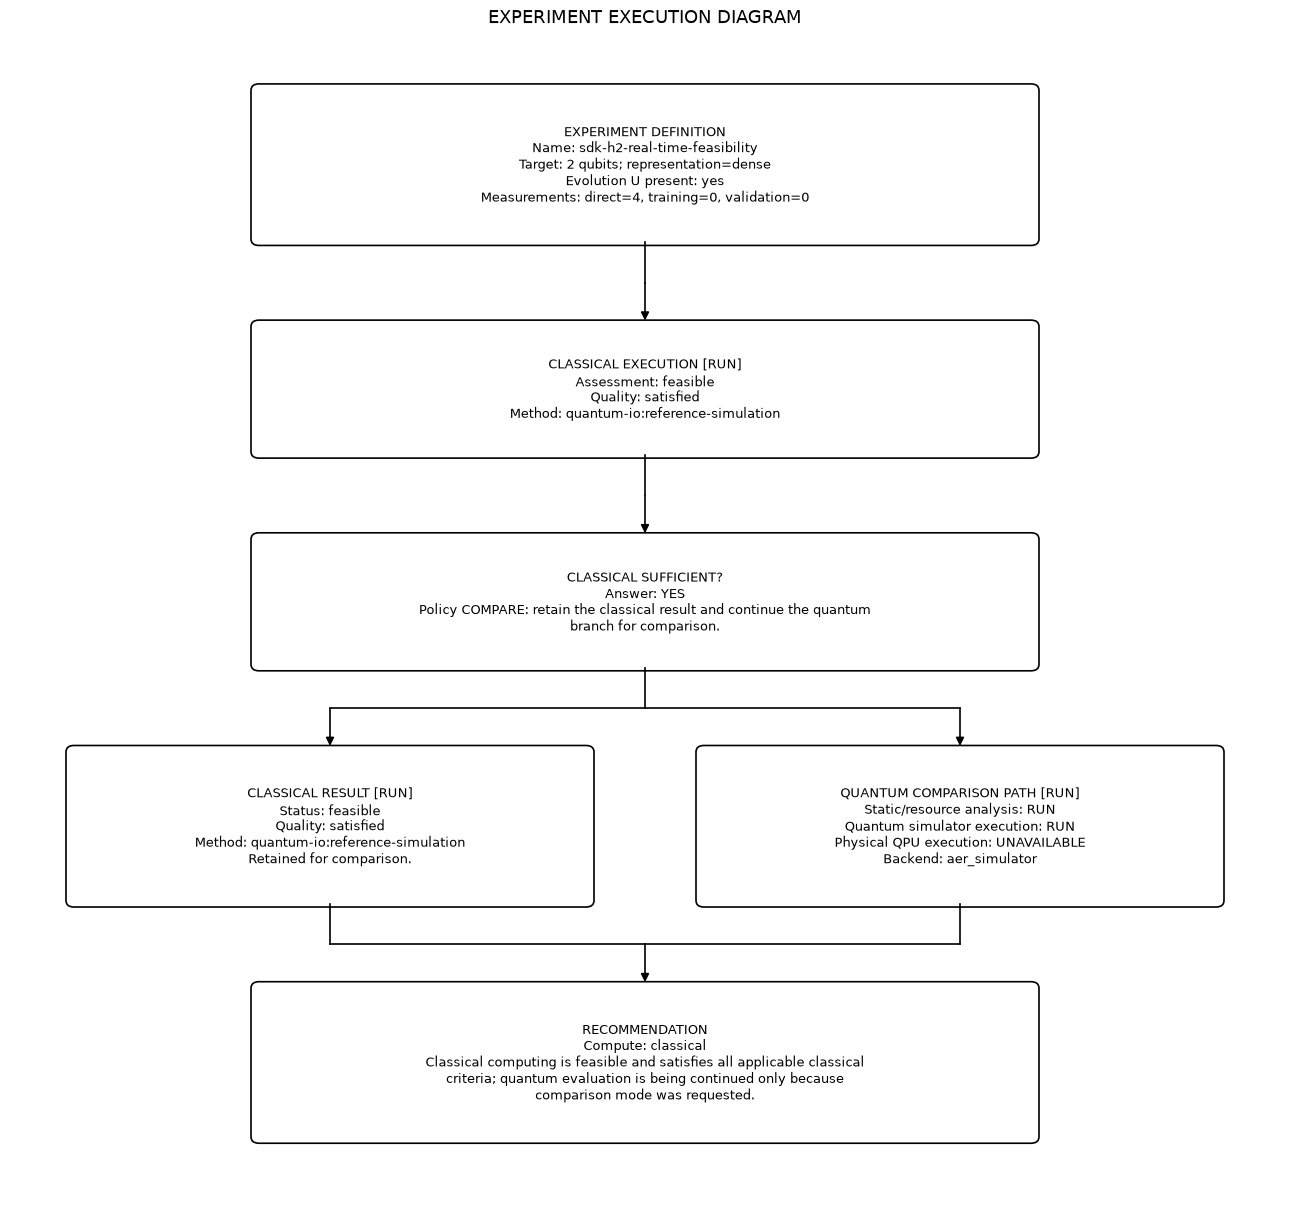

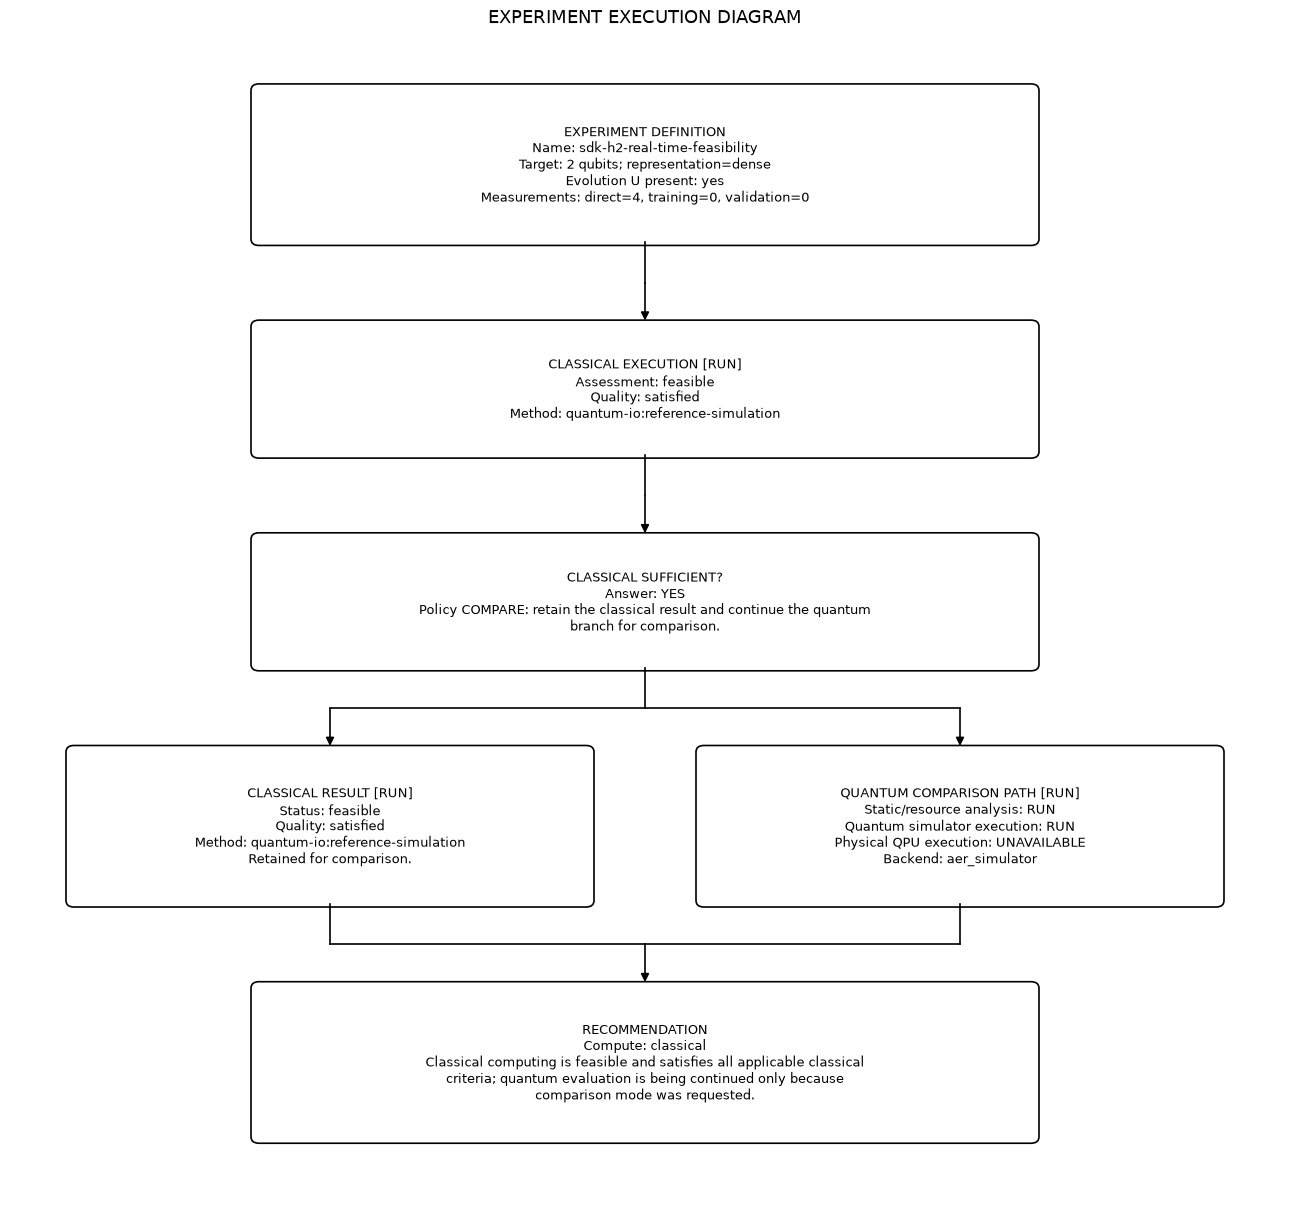

In [7]:
diagram = report.experiment_diagram
if diagram is None:
    print("No experiment diagram was returned.")
else:
    diagram_figure = diagram.draw(output="mpl", show_title=True)
    display(diagram_figure)

## 7. Quantum circuit

The returned circuit is reconstructed from the service's QASM 3 payload using Qiskit.
For this example it contains the H₂ Hartree–Fock preparation followed by the Trotterized
molecular evolution.

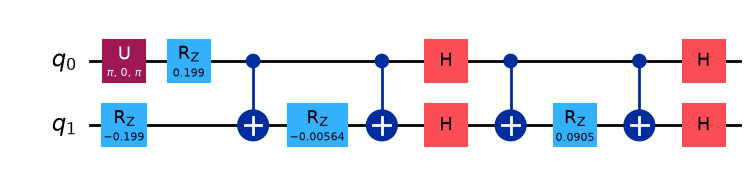

In [8]:
circuit = report.quantum_circuit
if circuit is None:
    print("No quantum circuit was returned.")
else:
    circuit_figure = circuit.draw(output="mpl")
    display(circuit_figure)

## Interpretation

This example intentionally uses a problem that is small enough to solve classically.
That is useful for feasibility analysis because the classical path provides a trustworthy
reference while `COMPARE` still exercises the configured quantum target.

For larger chemistry workloads, the same SDK structure remains unchanged: replace the
target wavefunction, evolution circuit, measurements, and resource/quality criteria.
The feasibility service—not the SDK—decides which evidence is sufficient and how the
classical and quantum paths compare.

In [9]:
from pprint import pprint

payload = report.to_dict()

pprint(payload["quantum"]["model_criteria"])

{'complete': False,
 'results': [{'criterion': {'label': None,
                            'metric': 'quality.observable_rmse',
                            'relation': '<=',
                            'required': True,
                            'threshold': 0.05},
              'evidence': None,
              'status': 'missing'}],
 'satisfied': False,
 'violated': False}


In [10]:
for record in payload["evidence"]["records"]:
    if "observable_rmse" in record.get("metric", ""):
        pprint(record)

{'generated_at': '2026-09-18T18:40:16.100327+00:00',
 'kind': 'simulated',
 'lower_bound': False,
 'metadata': {},
 'metric': 'quality.observable_rmse',
 'scope': 'classical',
 'source': 'quantum-io:exact-reference',
 'uncertainty': None,
 'unit': None,
 'value': 0.0}
{'generated_at': '2026-09-18T18:40:16.318872+00:00',
 'kind': 'simulated',
 'lower_bound': False,
 'metadata': {},
 'metric': 'quality.observable_rmse',
 'scope': 'classical',
 'source': 'quantum-io:exact-reference',
 'uncertainty': None,
 'unit': None,
 'value': 0.0}
{'generated_at': '2026-09-18T18:40:16.318872+00:00',
 'kind': 'simulated',
 'lower_bound': False,
 'metadata': {},
 'metric': 'quality.observable_rmse',
 'scope': 'classical',
 'source': 'aer_simulator',
 'uncertainty': None,
 'unit': None,
 'value': 0.003042257290109531}
